In [1]:
using Random:rand
using Printf: @sprintf, @printf
using Printf: @sprintf as @s
using LinearAlgebra: eigen, inv, pinv, diag, Diagonal, mul!
import LinearAlgebra.BLAS
using Statistics: mean, std
import CairoMakie
using CairoMakie: Figure, Axis, scatter!, lines!, save, errorbars!, errorbars, Cycled, axislegend, Label, ylims!
using CairoMakie: set_theme!, theme_latexfonts, update_theme!, rich
using CairoMakie: Relative, translate!
using LaTeXStrings: latexstring, @L_str
# import Logging: @warn
# using StyledStrings: @styled_str
import HDF5

In [2]:
BLAS.set_num_threads(1)

In [3]:
fig_path = "summary_figs"
mkpath(fig_path)

plot_prefix = "dual_g1_R_corner"

"dual_g1_R_corner"

In [4]:
set_theme!(theme_latexfonts())

update_theme!(;
    fontsize = 24,          # base font size for everything
    Axis = (
        titlesize      = 26,
        titlefont      = :bold,
        xlabelsize     = 24,
        ylabelsize     = 24,
        xticklabelsize = 18,
        yticklabelsize = 18,
    ),
    Legend = (
        labelsize  = 24,
    ),
)

In [5]:
const a_0 = 0.05 # in units of a
const g   = 1.0 # dimensionless g, in units of a^(-1/2)\
subtract_ratio = 1/2
const epsilon = 0.01

0.01

In [6]:
BLAS.set_num_threads(1)

In [7]:
function plaquette_i_to_coord(i, N=Ns)
    if i <= 0 || i > N^2
        throw(ArgumentError("i is out of range. Right now, i is $i"))
    end
    n_x = mod1(i, N)
    n_y = (i - 1) ÷ N + 1
    return n_x, n_y
end

function plaquette_coord_to_i(n_x, n_y, N=Ns)
    i = n_x + (n_y - 1) * N
    return i
end

function link_coord_to_i(n_x, n_y, p, N=Ns)
    if n_x <= N && n_y <= N
        return 2 * (n_x + (n_y-1) * N) - 1 + p
    elseif n_x == N+1 && n_y <= N
        if p == 1
            return 2 * N^2 + n_y
        else
            throw(ArgumentError("Not valid"))
        end
    elseif n_x <= N && n_y == N + 1
        if p == 0
            return 2 * N^2 + N + n_x
        else
            throw(ArgumentError("Not valid"))
        end
    else
        throw(ArgumentError("Index out of range. Here, n_x is $(n_x) and n_y is $(n_y)"))
    end
end

function link_i_to_coord(i, N=Ns)
    if 1 <= i <= 2 * N^2
        p = (i + 1) % 2
        tmp = div(i+1-p, 2)
        n_x = tmp % N
        n_y = div(tmp - 1, N) + 1
        return n_x, n_y, p
    elseif i <= 2 * N^2 + N
        n_x = N + 1
        n_y = i - 2 * N^2
        p = 1
        return n_x, n_y, p
    elseif i < 2 * N^2 + 2 * N
        n_x = i - 2 * N^2 - N
        n_y = N + 1
        p = 0
        return n_x, n_y, p
    else
        throw(ArgumentError("Index out of range"))
    end
end

# %%
plaquette_i_to_coord(1, 2)

# %%
link_coord_to_i(1, 1, 0, 2)

#%%
function get_mat_RtoE(N)
    n_col = N^2
    n_row = 2 * N^2 + 2 * N

    mat = zeros(n_row, n_col)

    for j in 1:n_col
        nx, ny = plaquette_i_to_coord(j, N)
        
        # edges
        i1 = link_coord_to_i(nx, ny, 0, N)
        i2 = link_coord_to_i(nx + 1, ny, 1, N)
        i3 = link_coord_to_i(nx, ny+1, 0, N)
        i4 = link_coord_to_i(nx, ny, 1, N)

        # fill in number
        mat[i1, j] = 1.
        mat[i2, j] = 1.
        mat[i3, j] = -1.
        mat[i4, j] = -1.
    end

    return mat
end

function get_mat_quad(mat_RtoE)
    return transpose(mat_RtoE) * mat_RtoE
end

function get_mat_quad_N(N)
    return get_mat_quad(get_mat_RtoE(N))
end

function get_t_max(M_quad)
    return 1 / maximum(diag(inv(M_quad)))
end

function get_t_max(N::Integer)
    return get_t_max(get_mat_quad_N(N))
end

get_t_max (generic function with 2 methods)

In [8]:
Ns_list = 2:2:14
eta_max_ls = get_t_max.(Ns_list)

7-element Vector{Float64}:
 3.4285714285714284
 2.4933887419720433
 2.165772428518602
 1.9819761706670223
 1.859102077930756
 1.7690106080396986
 1.6990411616691394

In [9]:
n = length(Ns_list)

energy_unmodified_ls       = Vector{Float64}(undef, n)
energy_unmodified_delta_ls = Vector{Float64}(undef, n)
R2_i_unmodified_ls        = Vector{Float64}(undef, n)
energy_R2_ls               = Vector{Float64}(undef, n)
energy_R2_delta_ls         = Vector{Float64}(undef, n)
R2_i_R2_ls                = Vector{Float64}(undef, n)
R2_i_R2_delta_ls          = Vector{Float64}(undef, n)

R2mean_unmodified_ls       = Vector{Float64}(undef, n)

output_path = "output"
for (i, Ns) in enumerate(Ns_list)
    name = "obc_R_ns$(Ns)"
    data_name = joinpath(output_path, name * ".h5")
    HDF5.h5open(data_name, "r") do f
        @assert a_0 ≈ HDF5.read(f["parameters/a_0"])
        @assert g   ≈ HDF5.read(f["parameters/g"])

        energy_unmodified_ls[i]        = HDF5.read(f["unmodified/energy_mean"])
        energy_unmodified_delta_ls[i]  = HDF5.read(f["unmodified/energy_delta"])
        R2_i_unmodified_ls[i]          = HDF5.read(f["unmodified/R2_i_mean"])
        energy_R2_ls[i]                = HDF5.read(f["R2/energy_mean"])
        energy_R2_delta_ls[i]          = HDF5.read(f["R2/energy_delta"])
        R2_i_R2_ls[i]                  = HDF5.read(f["R2/R2_i_mean"])
        R2_i_R2_delta_ls[i]            = HDF5.read(f["R2/R2_i_delta"])

        R2mean_unmodified_ls[i]       = mean(HDF5.read(f["unmodified/R2_mean"])) # this would be Ns*Ns array, but let's just average over it for simplicity
    end
end

In [10]:
function R2bound_from_energy(energy, eta_max; g=g, subtract_ratio=subtract_ratio)
    eta = eta_max * subtract_ratio
    return energy * 2 / g^2 / eta
end

function energy_from_R2(R2, eta_max; g=g, subtract_ratio=subtract_ratio)
    eta = eta_max * subtract_ratio
    return R2 / 2 * g^2 * eta
end

energy_from_R2 (generic function with 1 method)

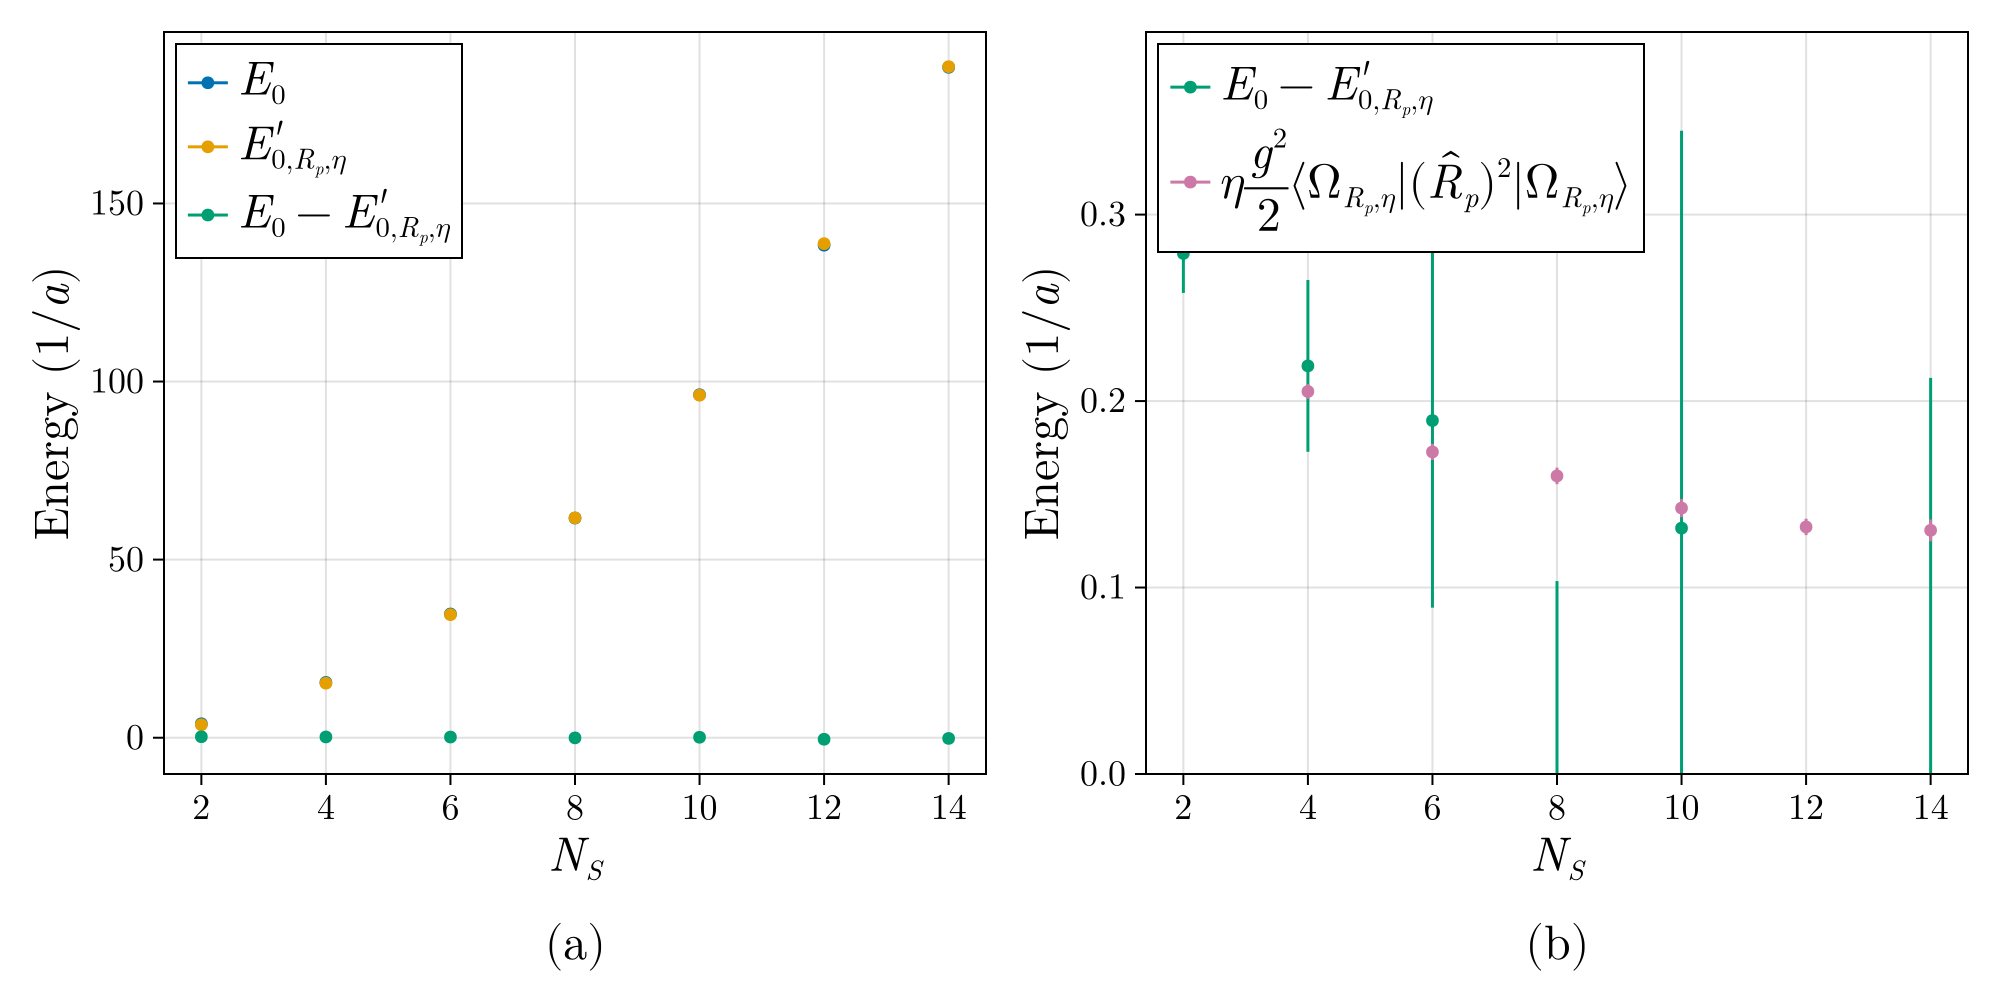

In [12]:
e_R2_i_R2       = energy_from_R2.(R2_i_R2_ls, eta_max_ls)
e_R2_i_R2_delta = energy_from_R2.(R2_i_R2_delta_ls, eta_max_ls)
e_R2_i_legend   = L"\eta \frac{g^2}{2}\langle \Omega_{R_p,\eta } | ( \hat{R}_p )^2  | \Omega_{R_p,\eta }\rangle"

f = Figure(;size=(1000, 500))
# ax1 = Axis(f[1, 1]; xlabel="Ns", ylabel="energy", title="Energy scale")
ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=L"Energy ($1/a$)", xticks = 0:2:14)

scatter!(ax1, Ns_list, energy_unmodified_ls; label=L"E_0")
errorbars!(ax1, Ns_list, energy_unmodified_ls, energy_unmodified_delta_ls, label=L"E_0")
scatter!(ax1, Ns_list, energy_R2_ls; label=L"E'_{0,R_p,\eta}")
errorbars!(ax1, Ns_list, energy_R2_ls, energy_R2_delta_ls; label=L"E'_{0,R_p,\eta}")
scatter!(ax1, Ns_list, energy_unmodified_ls .- energy_R2_ls; label=L"E_0-E'_{0,R_p,\eta}")
errorbars!(ax1, Ns_list, energy_unmodified_ls .- energy_R2_ls, hypot.(energy_unmodified_delta_ls, energy_R2_delta_ls); label=L"E_0-E'_{0,R_p,\eta}")

axislegend(ax1; position= :lt, merge=true)


ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel=L"Energy ($1/a$)", xticks = 0:2:14)
ylims!(ax2, (0, nothing))
scatter!(ax2, Ns_list, energy_unmodified_ls .- energy_R2_ls; label=L"E_0-E'_{0,R_p,\eta}", color=Cycled(3))
errorbars!(ax2, Ns_list, energy_unmodified_ls .- energy_R2_ls, hypot.(energy_unmodified_delta_ls, energy_R2_delta_ls); 
    label=L"E_0-E'_{0,R_p,\eta}", color=Cycled(3))
scatter!(ax2, Ns_list, e_R2_i_R2; label = e_R2_i_legend, color=Cycled(4))
errorbars!(ax2, Ns_list, e_R2_i_R2, e_R2_i_R2_delta; label = e_R2_i_legend, color=Cycled(4))
axislegend(ax2; position= :lt, merge=true)

Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)


f

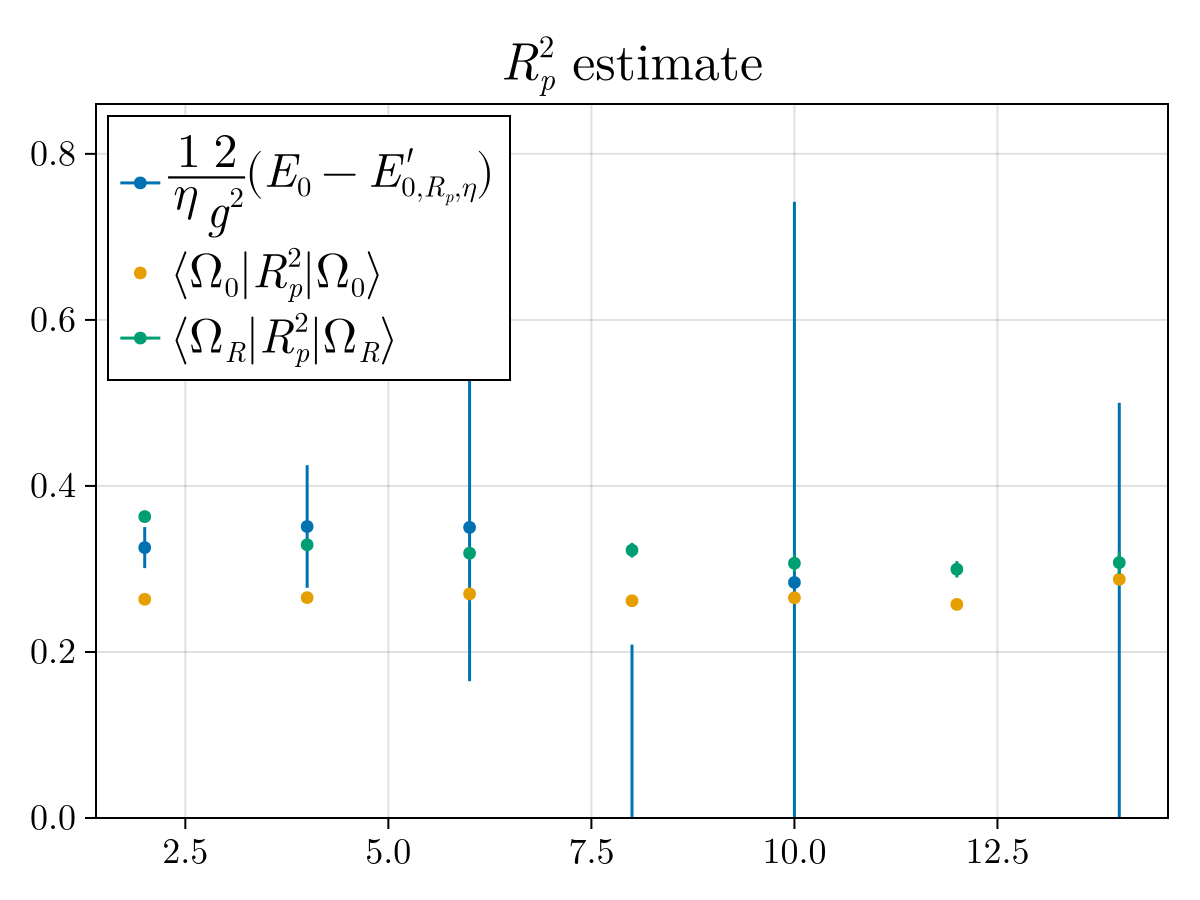

In [13]:
f = Figure()
ax = Axis(f[1, 1], title=L"$R_p^2$ estimate")
ylims!(ax, (0, nothing))

R2_naive_est = R2bound_from_energy.(energy_unmodified_ls, eta_max_ls)
R2_naive_est_delta = R2bound_from_energy.(energy_unmodified_delta_ls, eta_max_ls) # since this is a linear function

R2_est = R2bound_from_energy.(energy_unmodified_ls .- energy_R2_ls, eta_max_ls)
R2_est_delta = R2bound_from_energy.(hypot.(energy_unmodified_delta_ls, energy_R2_delta_ls), eta_max_ls) # since this is a linear function

scatter!(ax, Ns_list, R2_est; color = Cycled(1), label=L"\frac{1}{\eta} \frac{2}{g^2} (E_0-E'_{0,R_p,\eta})")
errorbars!(ax, Ns_list, R2_est, R2_est_delta; color = Cycled(1), label=L"\frac{1}{\eta} \frac{2}{g^2} (E_0-E'_{0,R_p,\eta})")
scatter!(ax, Ns_list, R2_i_unmodified_ls; color = Cycled(2), label=L"\langle \Omega_0 | R_{p}^2 | \Omega_0 \rangle")
scatter!(ax, Ns_list, R2_i_R2_ls; color = Cycled(3), label=L"\langle \Omega_R | R_{p}^2 | \Omega_R \rangle")
errorbars!(ax, Ns_list, R2_i_R2_ls, R2_i_R2_delta_ls; color = Cycled(3), label=L"\langle \Omega_R | R_{p}^2 | \Omega_R \rangle")

axislegend(ax; position= :lt, merge=true)


f

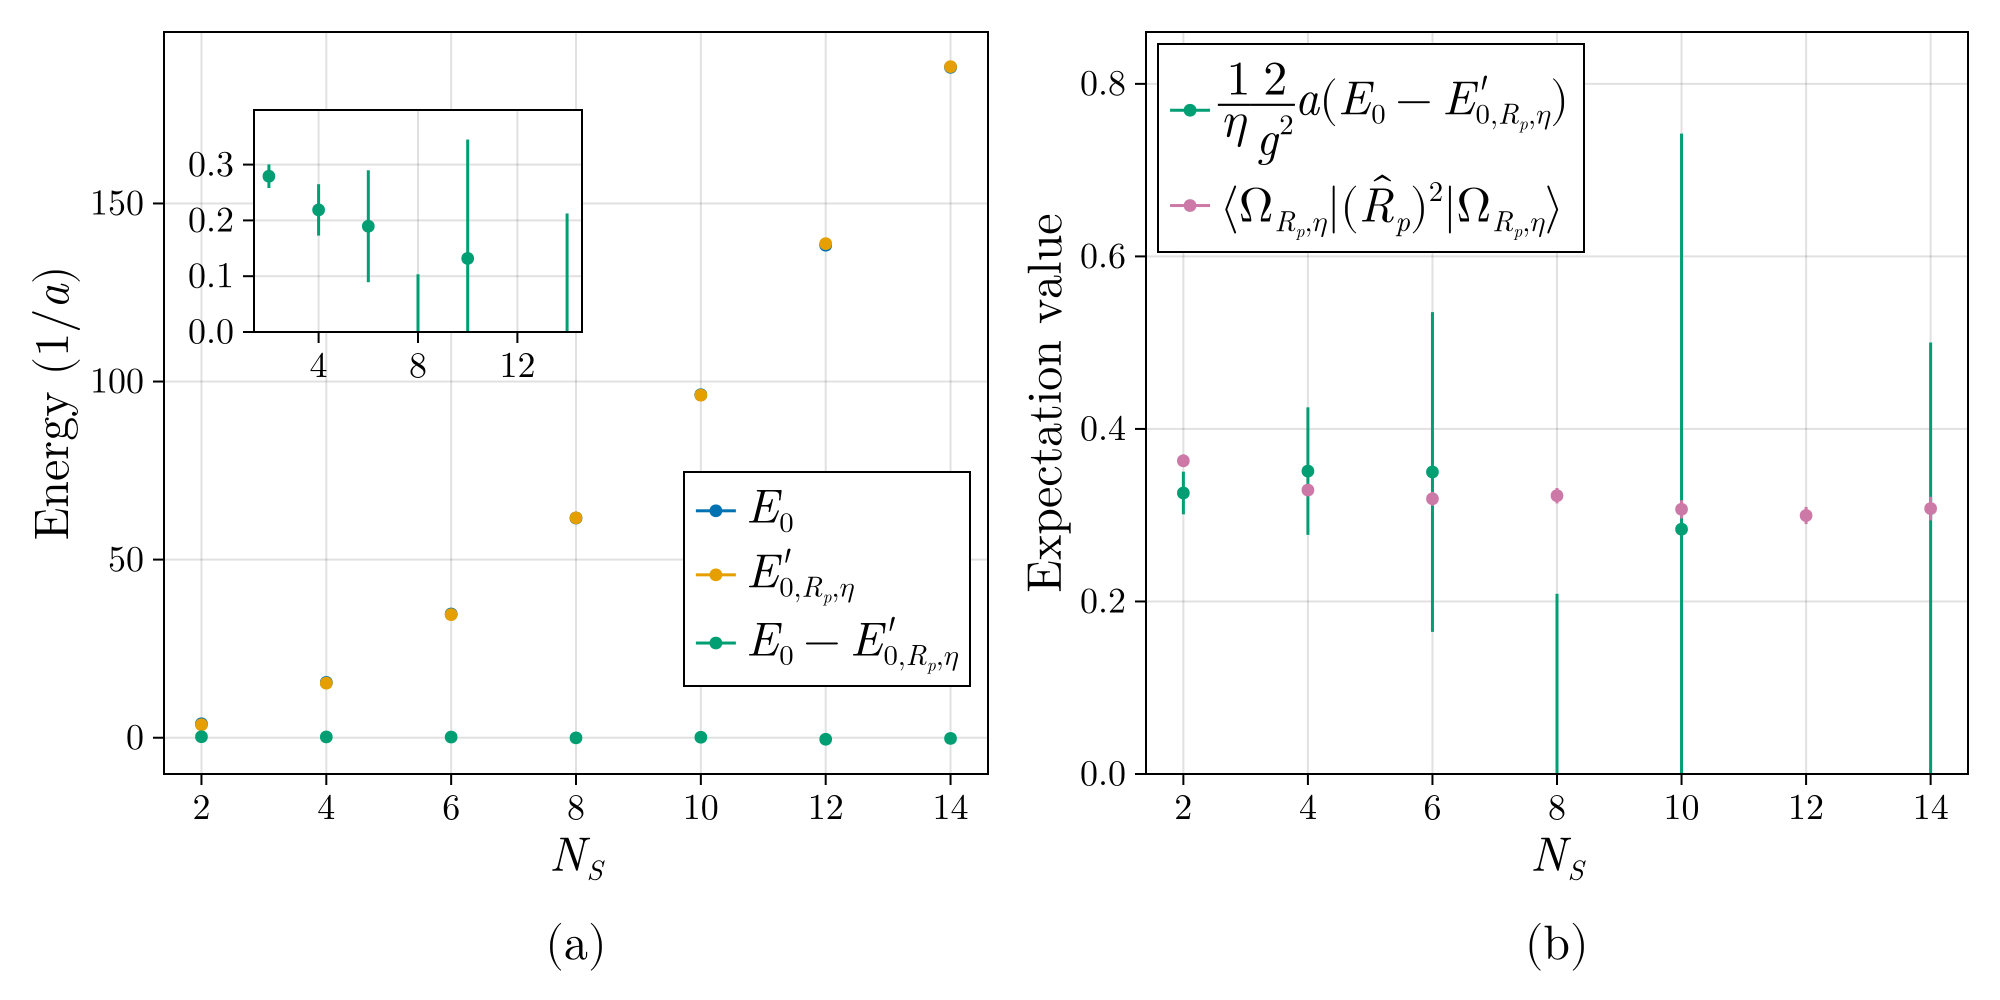

In [14]:
e_R2_i_R2       = energy_from_R2.(R2_i_R2_ls, eta_max_ls)
e_R2_i_R2_delta = energy_from_R2.(R2_i_R2_delta_ls, eta_max_ls)
e_R2_i_legend   = L"\eta \frac{g^2}{2}\langle \Omega_{R_p,\eta } | ( \hat{R}_p )^2  | \Omega_{R_p,\eta }\rangle"

f = Figure(;size=(1000, 500))
# ax1 = Axis(f[1, 1]; xlabel="Ns", ylabel="energy", title="Energy scale")
ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=L"Energy ($1/a$)", xticks = 0:2:14)

scatter!(ax1, Ns_list, energy_unmodified_ls; label=L"E_0")
errorbars!(ax1, Ns_list, energy_unmodified_ls, energy_unmodified_delta_ls, label=L"E_0")
scatter!(ax1, Ns_list, energy_R2_ls; label=L"E'_{0,R_p,\eta}")
errorbars!(ax1, Ns_list, energy_R2_ls, energy_R2_delta_ls; label=L"E'_{0,R_p,\eta}")
scatter!(ax1, Ns_list, energy_unmodified_ls .- energy_R2_ls; label=L"E_0-E'_{0,R_p,\eta}")
errorbars!(ax1, Ns_list, energy_unmodified_ls .- energy_R2_ls, hypot.(energy_unmodified_delta_ls, energy_R2_delta_ls); label=L"E_0-E'_{0,R_p,\eta}")

ax_inset = Axis(f[1,1]; width = Relative(0.4), height = Relative(0.3),
                halign = 0.18, valign = 0.85, xticks=(4:4:12))
translate!(ax_inset.blockscene, 0, 0, 150)

scatter!(ax_inset, Ns_list, energy_unmodified_ls .- energy_R2_ls; color=Cycled(3))
errorbars!(ax_inset, Ns_list, energy_unmodified_ls .- energy_R2_ls, hypot.(energy_unmodified_delta_ls, energy_R2_delta_ls); color=Cycled(3))
ylims!(ax_inset, (0, nothing))

axislegend(ax1; position= (0.99, 0.15), merge=true)



R2_est = R2bound_from_energy.(energy_unmodified_ls .- energy_R2_ls, eta_max_ls)
R2_est_delta = R2bound_from_energy.(hypot.(energy_unmodified_delta_ls, energy_R2_delta_ls), eta_max_ls) # since this is a linear function
legend_energydiff = L"\frac{1}{\eta} \frac{2}{g^2} a (E_0-E'_{0,R_p,\eta})"
legend_R2_i       = L"\langle \Omega_{R_p,\eta } | ( \hat{R}_p )^2  | \Omega_{R_p,\eta }\rangle"


ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel="Expectation value", xticks = 0:2:14)
ylims!(ax2, (0, nothing))

scatter!(ax2, Ns_list, R2_est; label=legend_energydiff, color=Cycled(3))
errorbars!(ax2, Ns_list, R2_est, R2_est_delta; label=legend_energydiff, color=Cycled(3))
scatter!(ax2, Ns_list, R2_i_R2_ls; label=legend_R2_i, color=Cycled(4))
errorbars!(ax2, Ns_list, R2_i_R2_ls, R2_i_R2_delta_ls; label=legend_R2_i, color=Cycled(4))
axislegend(ax2; position= :lt, merge=true)

Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)

save(joinpath(fig_path, "$(plot_prefix)_energy_plot.pdf"), f)

f

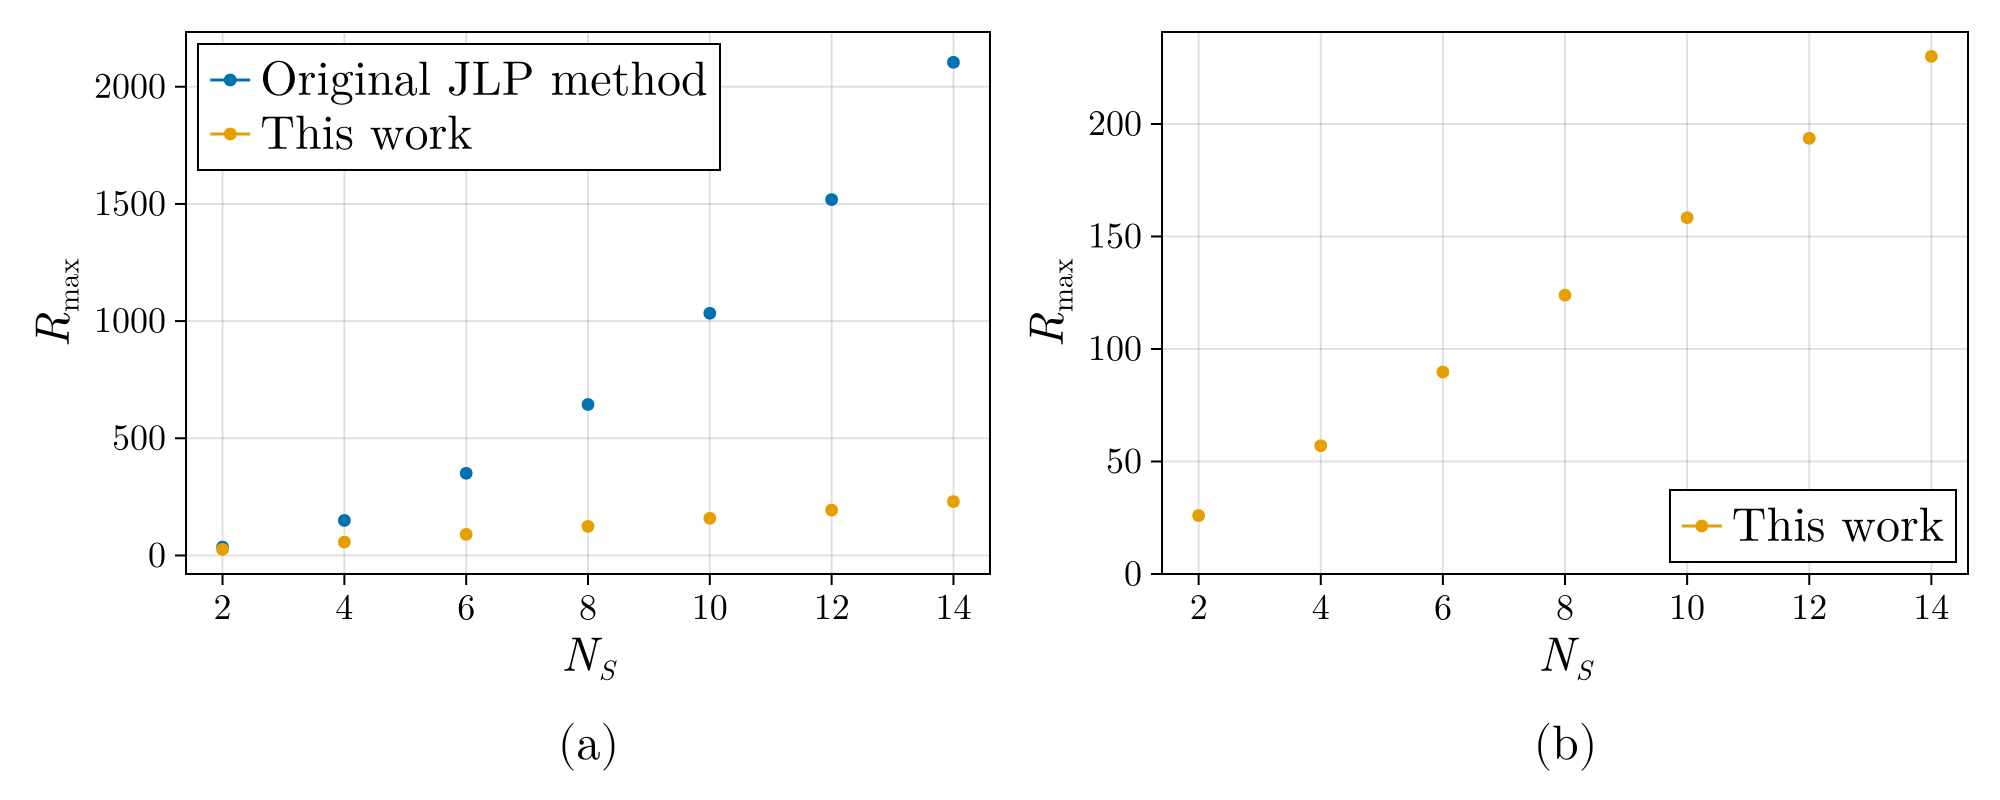

In [15]:
f = Figure(;size=(1000, 400))
e_free = 1.0


volume_ls = Ns_list .^ 2
factor_ls = sqrt.(volume_ls ./ epsilon ) .+ 1

bound_R2_naive         = R2bound_from_energy.(energy_unmodified_ls .+ e_free, eta_max_ls; subtract_ratio = 1.0)
bound_R2_naive_delta   = R2bound_from_energy.(energy_unmodified_delta_ls, eta_max_ls;  subtract_ratio = 1.0)
bound_Rrms_naive       = sqrt.(bound_R2_naive)
bound_Rrms_naive_delta = bound_R2_naive_delta ./ bound_Rrms_naive / 2
R_trunc_naive          = factor_ls .* bound_Rrms_naive
R_trunc_naive_delta    = factor_ls .* bound_Rrms_naive_delta


ΔE_upper            = energy_from_R2.(R2_i_R2_ls, eta_max_ls)
bound_R2_im         = R2bound_from_energy.(ΔE_upper .+ e_free, eta_max_ls)
bound_R2_im_delta   = R2_i_R2_delta_ls
bound_Rrms_im       = sqrt.(bound_R2_im)
bound_Rrms_im_delta = bound_R2_im_delta ./ bound_Rrms_im / 2
R_trunc_im          = factor_ls .* bound_Rrms_im
R_trunc_im_delta    = factor_ls .* bound_Rrms_im_delta

# ylabel_compare = L"Truncation for $R$"
ylabel_compare = L"R_\text{max}"

# here, for the naive method, we need to multiple by sqrt(Volume) factor
ax1 = Axis(f[1, 1]; xlabel=L"N_S", ylabel=ylabel_compare, xticks = 0:2:14)
scatter!(ax1, Ns_list, R_trunc_naive; label="Original JLP method")
errorbars!(ax1, Ns_list, R_trunc_naive, R_trunc_naive_delta .* Ns_list; label="Original JLP method")
scatter!(ax1, Ns_list, R_trunc_im; label="This work")
errorbars!(ax1, Ns_list, R_trunc_im, R_trunc_im_delta; label="This work")
axislegend(ax1; position=:lt, merge=true)


# here, for the naive method, we need to multiple by sqrt(Volume) factor
ax2 = Axis(f[1, 2]; xlabel=L"N_S", ylabel=ylabel_compare, xticks = 0:2:14)
ylims!(ax2, (0, nothing))
scatter!(ax2, Ns_list, R_trunc_im; label="This work", color=Cycled(2))
errorbars!(ax2, Ns_list, R_trunc_im, R_trunc_im_delta; label="This work", color=Cycled(2))
axislegend(ax2; position=:rb, merge=true)

Label(f[2, 1], "(a)"; tellwidth=false)
Label(f[2, 2], "(b)"; tellwidth=false)


save(joinpath(fig_path, "$(plot_prefix)_bound_compare.pdf"), f)


f

In [16]:
i = 2
println("At N_S = $(Ns_list[i])")
println("We have naive R trunc as $(R_trunc_naive[i])")
println("And improved R trunc at $(R_trunc_im[i])")
ratio = R_trunc_naive[i] / R_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 4
We have naive R trunc as 149.28830918812892
And improved R trunc at 57.00832400666841
With saving factor being roughly 2.6187107196953603


In [17]:
i = 4
println("At N_S = $(Ns_list[i])")
println("We have naive R trunc as $(R_trunc_naive[i])")
println("And improved R trunc at $(R_trunc_im[i])")
ratio = R_trunc_naive[i] / R_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 8
We have naive R trunc as 644.1557868531104
And improved R trunc at 123.92763250482813
With saving factor being roughly 5.19783823698895


In [18]:
i = 6
println("At N_S = $(Ns_list[i])")
println("We have naive R trunc as $(R_trunc_naive[i])")
println("And improved R trunc at $(R_trunc_im[i])")
ratio = R_trunc_naive[i] / R_trunc_im[i]
println("With saving factor being roughly $(ratio)")

At N_S = 12
We have naive R trunc as 1518.3282578128649
And improved R trunc at 193.62889273288835
With saving factor being roughly 7.841434387105665
